## tifファイルのデータが大きすぎるので21600×43200、ちょっと粗目に描画

original size: 21600 43200
display size: (1080, 2160)
unique values: [-9999  -357  -333 ...  6154  6227  6280]


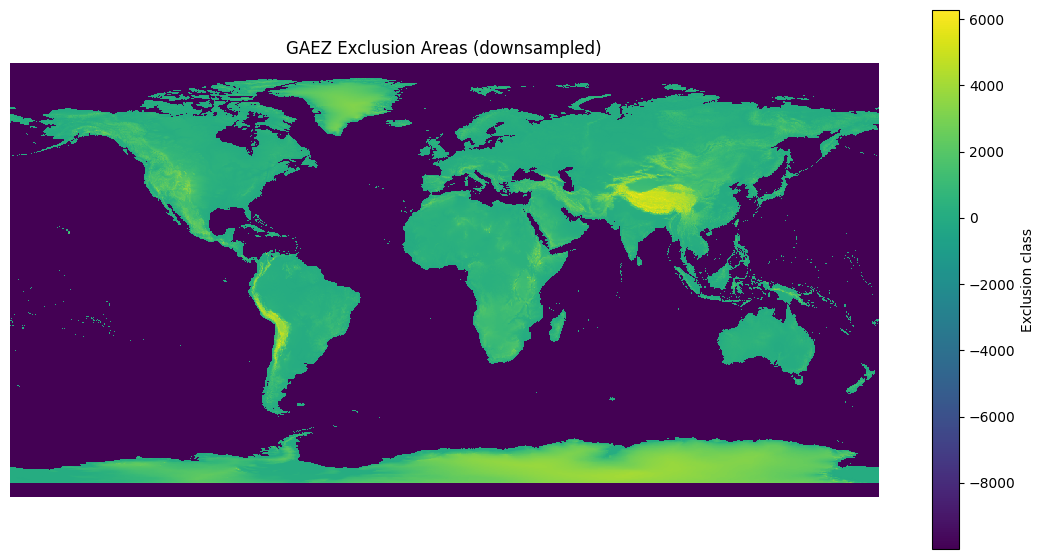

In [7]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

tif_path = r"C:\masterresearch\Comparative_advantage\GAEZ\elevation.tif"

# =========================
# 表示用に粗く読む
# =========================

scale = 20  # 20倍粗くする。重ければ 40, 60 に上げる

with rasterio.open(tif_path) as src:
    out_height = src.height // scale
    out_width  = src.width // scale

    arr = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=Resampling.nearest  # カテゴリデータなので nearest
    )

print("original size:", src.height, src.width)
print("display size:", arr.shape)
print("unique values:", np.unique(arr))

# =========================
# 可視化
# =========================

plt.figure(figsize=(14, 7))
plt.imshow(arr, interpolation="nearest")
plt.colorbar(label="Exclusion class")
plt.title("GAEZ Exclusion Areas (downsampled)")
plt.axis("off")
plt.show()

## 3と4(自然保護区)だけ描画してみる

C:\Users\tsuda\AppData\Local\Temp\ipykernel_14872\3608248681.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("Set1", 2)


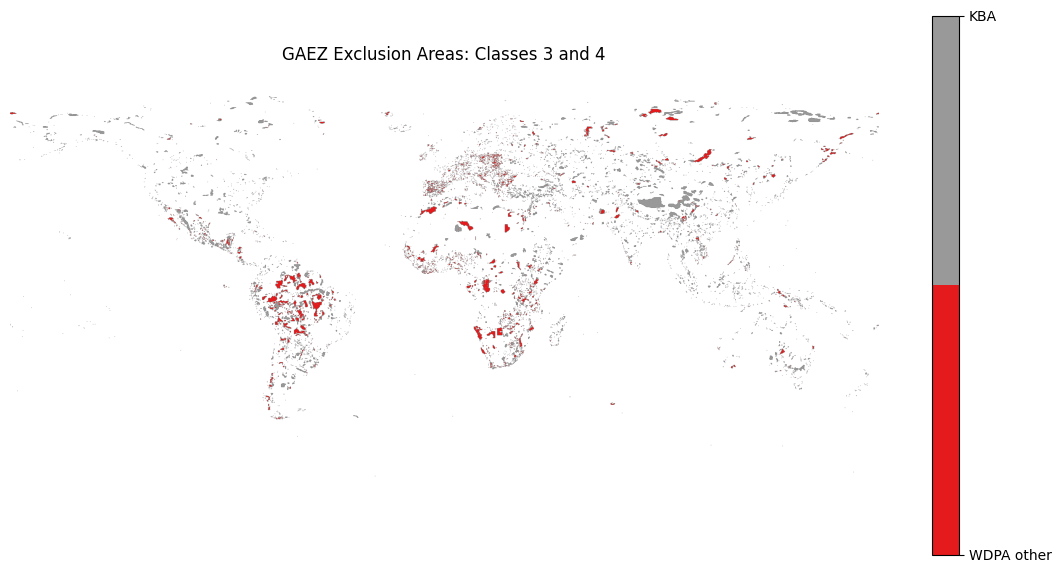

In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

tif_path = r"C:\masterresearch\Comparative_advantage\GAEZ\exclusion.tif"

# 表示用に縮小
scale = 20

with rasterio.open(tif_path) as src:
    arr = src.read(
        1,
        out_shape=(
            src.height // scale,
            src.width // scale
        ),
        resampling=Resampling.nearest
    )

# =========================
# 3と4だけ抽出
# =========================

mask = np.isin(arr, [3, 4])

plot_arr = np.full(arr.shape, np.nan)
plot_arr[arr == 3] = 3
plot_arr[arr == 4] = 4

# =========================
# 描画
# =========================

plt.figure(figsize=(14, 7))

cmap = plt.cm.get_cmap("Set1", 2)
im = plt.imshow(plot_arr, cmap=cmap)

cbar = plt.colorbar(im, ticks=[3, 4])
cbar.ax.set_yticklabels([
    "WDPA other",
    "KBA"
])

plt.title("GAEZ Exclusion Areas: Classes 3 and 4")
plt.axis("off")
plt.show()